## Notebook 08 — Market Regime Analysis

### Crypto Alpha Research Lab (CARL)

This notebook classifies Bitcoin into distinct market regimes based on daily return dynamics. Market regime identification provides a structured framework for distinguishing expansionary and contractionary market conditions, supporting risk management, portfolio allocation, and systematic investment decisions.

### Research Objective

The objectives of this notebook are to:

- Compute daily arithmetic returns.
- Classify market observations into bull and bear regimes.
- Examine the frequency of each regime.
- Visualize regime transitions over time.

In [1]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

from crypto_alpha_lab.data.storage import load_prices

from asset_pricing_lab.returns import arithmetic_returns

In [2]:
btc = load_prices(
    ticker="BTC-USD",
    start="2020-01-01",
    end="2026-06-20",
)

btc.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [10]:
btc["Returns"] = arithmetic_returns(btc["Close"]).dropna(inplace=False)

print(btc["Returns"])

Date
2020-01-01         NaN
2020-01-02   -0.029819
2020-01-03    0.051452
2020-01-04    0.008955
2020-01-05    0.000089
                ...   
2026-06-15    0.008813
2026-06-16   -0.010392
2026-06-17   -0.018021
2026-06-18   -0.023626
2026-06-19    0.010245
Name: Returns, Length: 2362, dtype: float64


Arithmetic returns provide the basis for identifying prevailing market conditions. Daily return behavior serves as a simple yet informative indicator of short-term market direction and forms the foundation for regime classification.

In [12]:
btc["Regime"] = "Bear"

btc.loc[
    btc["Returns"] >= 0,
    "Regime"
] = "Bull"

btc.head()

Price,Close,High,Low,Open,Volume,Returns,Regime
Date,,,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997,NaN,Bear
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465,-0.029819,Bear
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032,0.051452,Bull
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275,0.008955,Bull
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095,0.000089,Bull


Market regimes are classified according to the sign of daily returns. Positive returns indicate bullish conditions associated with upward price momentum, whereas negative returns represent bearish conditions characterized by declining market performance.

In [13]:
regime_counts = btc["Regime"].value_counts()

regime_counts

Regime
Bull    1196
Bear    1166
Name: count, dtype: int64

The distribution of market regimes summarizes the relative frequency of positive and negative trading sessions, providing a simple measure of market persistence over the sample period. From the values obtained, the bullish regime of 1196 is slitly higher than the bear regime of 1166. This indicated that during the period of observation,bitcoin return went up more than it declined.

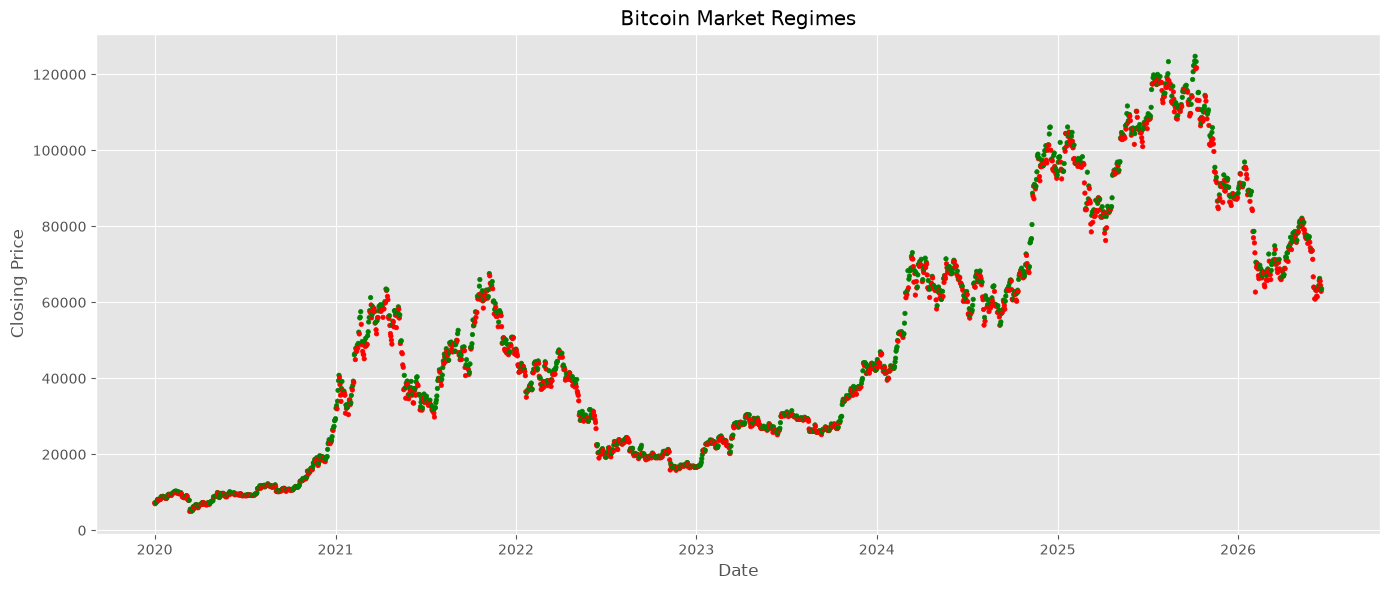

In [14]:
plt.figure(figsize=(14, 6))

colors = btc["Regime"].map(
    {
        "Bull": "green",
        "Bear": "red",
    }
)

plt.scatter(
    btc.index,
    btc["Close"],
    c=colors,
    s=10,
)

plt.title("Bitcoin Market Regimes")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.tight_layout()

plt.show()

### Interpretation

The market regime classification highlights alternating periods of bullish and bearish conditions throughout the sample. Persistent clusters of positive returns indicate sustained upward market momentum, whereas extended sequences of negative returns reflect periods of heightened downside pressure. Regime identification provides a practical framework for evaluating market dynamics and forms a foundation for more advanced state-dependent portfolio allocation and quantitative trading models.